In [48]:
!pip install keras_facenet
import tensorflow as tf
from keras_facenet import FaceNet
import numpy as np
from tensorflow.keras import layers, models
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

In [2]:
def resize_to_160(img):
    """
    img: Tensor or numpy array of shape (256, 256, 3)
    returns: Tensor (160, 160, 3)
    """
    img = tf.image.resize(img, (160, 160), method='bilinear')
    img = img.numpy()
    return img

In [32]:
def get_embedding(img):
  """
  The embedder.embeddings function expects a list of numpy arrays.
  img is already a numpy array from resize_to_160, so we wrap it in a list.
  """
  img = resize_to_160(img)
  emb = embedder.embeddings([img])[0]
  #emb = np.expand_dims(emb, axis=0)
  return emb

In [33]:
def process_row(row):
    row["embedding"] = get_embedding(row["image"])
    return row

In [34]:
from datasets import load_dataset

ds = load_dataset("tonyassi/celebrity-1000")

In [35]:
ds['train'].shape

(18184, 2)

In [36]:
embedder = FaceNet()

In [37]:
split_ds = ds['train'].train_test_split(test_size=0.2, stratify_by_column="label")

In [38]:
split_ds.shape
train = split_ds['train']
test = split_ds['test']
print(train.shape)
print(test.shape)

(14547, 2)
(3637, 2)


In [39]:
keep = list(range(50))
train_50 = train.filter(lambda x: x["label"] in keep)
test_50  = test.filter(lambda x: x["label"] in keep)


Filter:   0%|          | 0/14547 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3637 [00:00<?, ? examples/s]

In [40]:
print(train_50.shape)
print(test_50.shape)

(716, 2)
(179, 2)


In [ ]:
train_50 = train_50.map(process_row)
test_50  = test_50.map(process_row)

In [42]:
model = models.Sequential([
    layers.Input(shape=(512,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(50, activation='softmax')
])


In [43]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [44]:
x_train = np.array(train_50["embedding"])
y_train = np.array(train_50["label"])
x_test = np.array(test_50["embedding"])
y_test = np.array(test_50["label"])

In [45]:
model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.1467 - loss: 3.8587 - val_accuracy: 0.8045 - val_loss: 3.6551
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7928 - loss: 3.5689 - val_accuracy: 0.9330 - val_loss: 3.2912
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8834 - loss: 3.1746 - val_accuracy: 0.9441 - val_loss: 2.8027
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9312 - loss: 2.6359 - val_accuracy: 0.9497 - val_loss: 2.2251
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9404 - loss: 2.0578 - val_accuracy: 0.9777 - val_loss: 1.6467
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9536 - loss: 1.4926 - val_accuracy: 0.9777 - val_loss: 1.1492
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9695 - loss: 1.0661 - val_accuracy: 0.9777 - val_loss: 0.7880
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9851 - loss: 0.7669 - val_accuracy: 0.9832 - val_loss

In [46]:
loss, acc = model.evaluate(x_train, y_train)
print("Accuracy:", acc)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9922 - loss: 0.2532
Accuracy: 0.99301677942276


In [91]:
def get_prediction(img):
  emb = get_embedding(img)
  emb = np.expand_dims(emb, axis=0)
  predictions = model.predict(emb)
  predicted_class = np.argmax(predictions)
  print(f"\nPredicted Class Index: {predicted_class}")
  print(f"Name: {ds['train'].features['label'].names[predicted_class]}")
  print(f"Confidence: {np.max(predictions) * 100:.2f}%")

  predictions = np.sort(predictions)[0,::-1]
  print(f"Classes: {predictions[:10]}")

In [65]:
from mtcnn import MTCNN
import numpy as np
import cv2

detector = MTCNN()

def crop_face_mtcnn(img, required_size=(160, 160)):
    """
    Detects a face using MTCNN and returns a cropped RGB face.
    The input MUST be an RGB uint8 numpy array.
    """

    results = detector.detect_faces(img)
    if len(results) == 0:
        return None

    x, y, w, h = results[0]['box']

    x = max(0, x)
    y = max(0, y)
    x2 = min(x + w, img.shape[1])
    y2 = min(y + h, img.shape[0])

    face = img[y:y2, x:x2]

    if face.size == 0:
        return None

    face = cv2.resize(face, required_size)

    return face


Saving intro-1537199679.jpg to intro-1537199679 (15).jpg


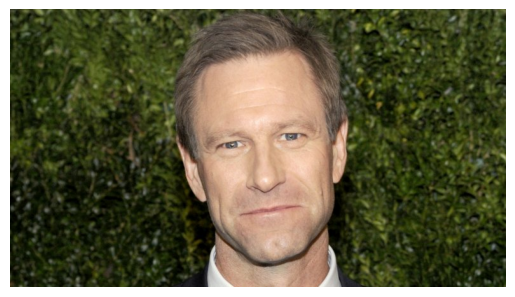

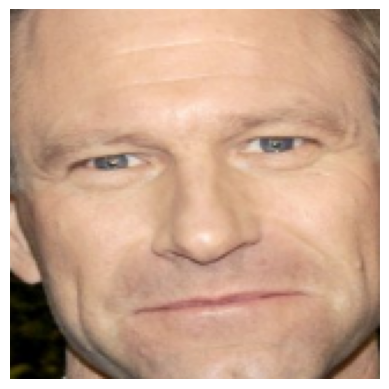

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

Predicted Class Index: 0
Name: Aaron Eckhart
Confidence: 63.39%
Classes: [0.63394266 0.05821815 0.02687214 0.02352528 0.0185161  0.01725055
 0.01625474 0.01447946 0.0132429  0.01235469]


In [92]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_pil = load_img(filename)
img = np.array(img_pil).astype('uint8')

plt.imshow(img)
plt.axis('off')
plt.show()

cropped = crop_face_mtcnn(img)

if cropped is not None:
  cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
  plt.imshow(cropped_rgb)
  plt.axis('off')
  plt.show()
else:
  print("No face detected")

if cropped is None:
  print("No face detected")
else:
  get_prediction(cropped)